# 01: Exploratory Data Analysis (EDA)

## Objectives
1. Load and understand the Telco customer churn dataset
2. Analyze distributions and relationships
3. Identify patterns and anomalies
4. Generate publication-quality visualizations
5. Document key findings

## Dataset
- **Source**: WA_Fn-UseC_-Telco-Customer-Churn.csv
- **Records**: ~7,000 customers
- **Features**: Demographic, service, and account information
- **Target**: Churn (Yes/No)

In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
from pathlib import Path

# Add src to path
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))

# Import custom modules
from data_loader import TelcoDataLoader, load_telco_data
from preprocessing import DataPreprocessor, preprocess_data

# Configure plotting
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

In [2]:
# Data Loading and Validation
# Specify the path to your dataset
data_path = '../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv'

# Load data
try:
    loader = TelcoDataLoader(data_path)
    raw_data = loader.load_data()
    print("✓ Data loaded successfully")
    print(f"Shape: {raw_data.shape}")
except FileNotFoundError:
    print(f"⚠ Data file not found at {data_path}")
    print("Please place your Telco dataset in the data/raw/ directory")

2026-07-18 14:09:59,769 - data_loader - INFO - Data loaded successfully. Shape: (7043, 21)


✓ Data loaded successfully
Shape: (7043, 21)


In [3]:
# Display basic information
print("=" * 80)
print("DATASET OVERVIEW")
print("=" * 80)
print(f"\nShape: {raw_data.shape}")
print(f"Columns: {raw_data.columns.tolist()}")
print(f"\nData Types:\n{raw_data.dtypes}")
print(f"\nMissing Values:\n{raw_data.isnull().sum()[raw_data.isnull().sum() > 0]}")

DATASET OVERVIEW

Shape: (7043, 21)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data Types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Missing Values:

In [4]:
# Data Cleaning
print("\n" + "=" * 80)
print("DATA PREPROCESSING")
print("=" * 80)

preprocessor = DataPreprocessor()
cleaned_data = preprocessor.preprocess(raw_data)

# Convert Churn to numeric (0 = No, 1 = Yes)
cleaned_data['Churn'] = (cleaned_data['Churn'] == 'Yes').astype(int)

print(f"\nCleaned data shape: {cleaned_data.shape}")
print(f"Removed columns: customerID")
print(f"Missing values after cleaning: {cleaned_data.isnull().sum().sum()}")
print(f"Churn values: {cleaned_data['Churn'].unique()}")

2026-07-18 14:10:03,280 - preprocessing - INFO - Starting preprocessing pipeline
2026-07-18 14:10:03,284 - preprocessing - INFO - Removed customerID column
C:\Users\lenovo\telco-churn-explainability\notebooks\..\src\preprocessing.py:66: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  data['TotalCharges'].fillna(median_charges, inplace=


DATA PREPROCESSING

Cleaned data shape: (7043, 20)
Removed columns: customerID
Missing values after cleaning: 11
Churn values: [0 1]



CHURN DISTRIBUTION

Churn Distribution:
  No Churn: 5,174 (73.46%)
  Churn: 1,869 (26.54%)


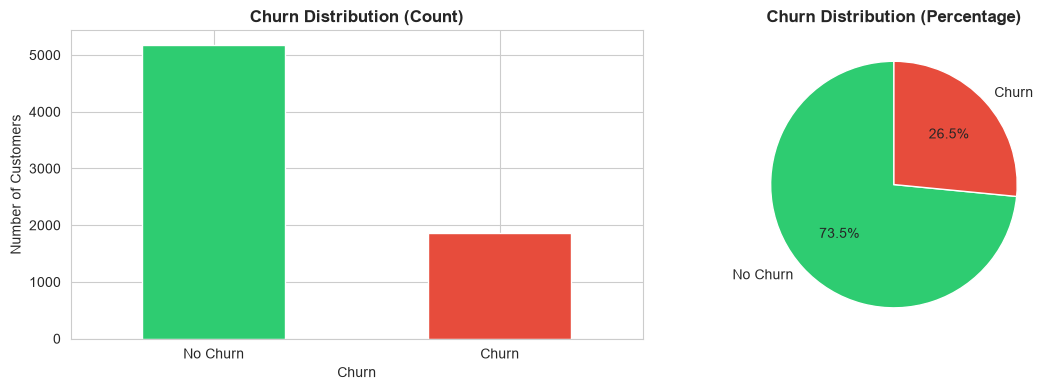

✓ Churn distribution plot saved


In [5]:
# Churn Distribution
print("\n" + "=" * 80)
print("CHURN DISTRIBUTION")
print("=" * 80)

churn_counts = cleaned_data['Churn'].value_counts().sort_index()
churn_pct = cleaned_data['Churn'].value_counts(normalize=True).sort_index() * 100

print(f"\nChurn Distribution:")
print(f"  No Churn: {churn_counts[0]:,} ({churn_pct[0]:.2f}%)")
print(f"  Churn: {churn_counts[1]:,} ({churn_pct[1]:.2f}%)")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot - sort for consistent display
churn_labels = ['No Churn', 'Churn']
churn_counts.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Churn Distribution (Count)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Number of Customers')
axes[0].set_xticklabels(churn_labels, rotation=0)

# Pie chart
axes[1].pie(churn_counts, labels=churn_labels, autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Churn Distribution (Percentage)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/figures/01_churn_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Churn distribution plot saved")


TENURE ANALYSIS


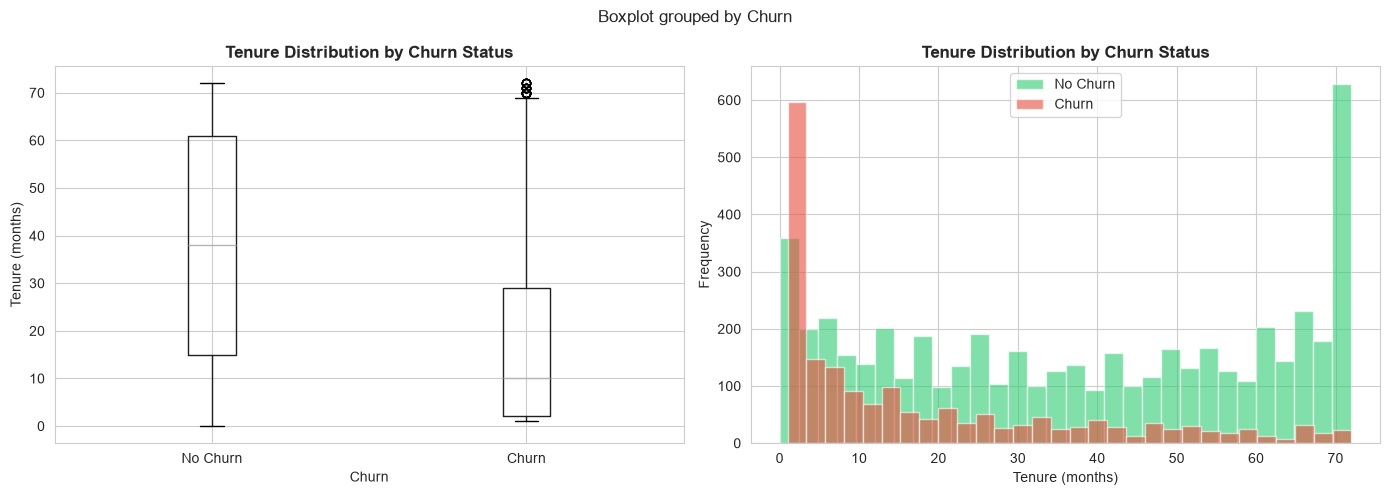


Tenure Statistics:
  No Churn - Mean: 37.6 months
  Churn - Mean: 18.0 months
✓ Tenure analysis plot saved


In [6]:
# Tenure vs Churn Analysis
print("\n" + "=" * 80)
print("TENURE ANALYSIS")
print("=" * 80)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
cleaned_data.boxplot(column='tenure', by='Churn', ax=axes[0])
axes[0].set_title('Tenure Distribution by Churn Status', fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Tenure (months)')
axes[0].set_xticklabels(['No Churn', 'Churn'])

# Histogram
for churn_status in [0, 1]:
    label = 'Churn' if churn_status == 1 else 'No Churn'
    color = '#e74c3c' if churn_status == 1 else '#2ecc71'
    axes[1].hist(cleaned_data[cleaned_data['Churn'] == churn_status]['tenure'],
                alpha=0.6, label=label, bins=30, color=color)

axes[1].set_title('Tenure Distribution by Churn Status', fontweight='bold')
axes[1].set_xlabel('Tenure (months)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/figures/02_tenure_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nTenure Statistics:")
print(f"  No Churn - Mean: {cleaned_data[cleaned_data['Churn']==0]['tenure'].mean():.1f} months")
print(f"  Churn - Mean: {cleaned_data[cleaned_data['Churn']==1]['tenure'].mean():.1f} months")
print("✓ Tenure analysis plot saved")


MONTHLY CHARGES ANALYSIS


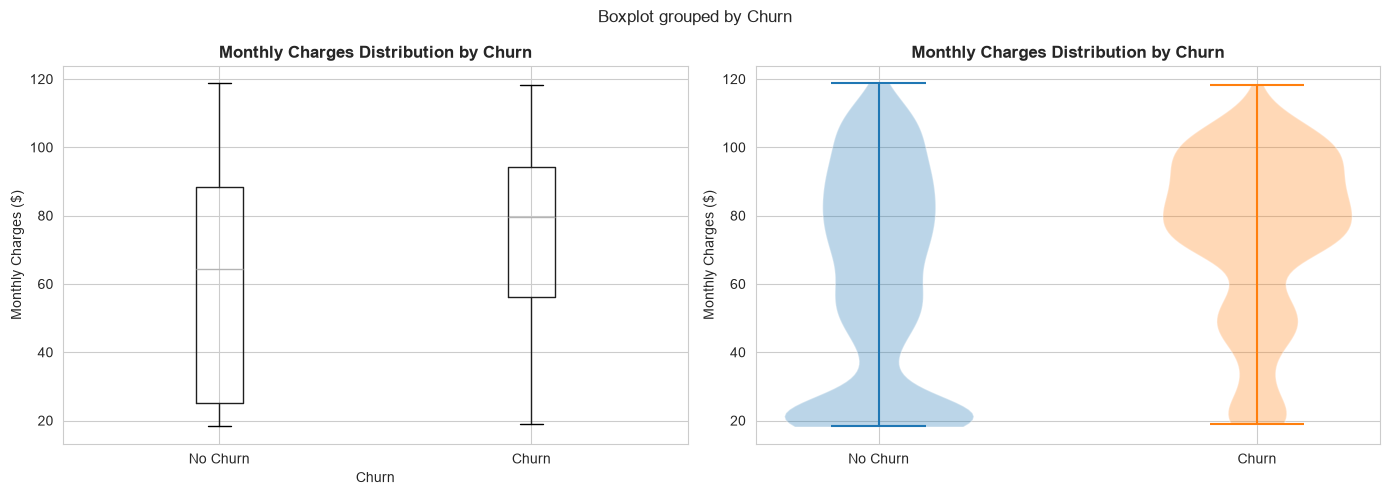


Monthly Charges Statistics:
  No Churn - Mean: $61.27
  Churn - Mean: $74.44
✓ Monthly charges analysis plot saved


In [7]:
# Monthly Charges vs Churn
print("\n" + "=" * 80)
print("MONTHLY CHARGES ANALYSIS")
print("=" * 80)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
cleaned_data.boxplot(column='MonthlyCharges', by='Churn', ax=axes[0])
axes[0].set_title('Monthly Charges Distribution by Churn', fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Monthly Charges ($)')
axes[0].set_xticklabels(['No Churn', 'Churn'])

# Violin plot
for idx, churn_status in enumerate([0, 1]):
    label = 'No Churn' if churn_status == 0 else 'Churn'
    color = '#2ecc71' if churn_status == 0 else '#e74c3c'
    charges = cleaned_data[cleaned_data['Churn'] == churn_status]['MonthlyCharges']
    axes[1].violinplot([charges], positions=[idx], widths=0.5)

axes[1].set_title('Monthly Charges Distribution by Churn', fontweight='bold')
axes[1].set_ylabel('Monthly Charges ($)')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['No Churn', 'Churn'])

plt.tight_layout()
plt.savefig('../outputs/figures/03_monthly_charges_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nMonthly Charges Statistics:")
print(f"  No Churn - Mean: ${cleaned_data[cleaned_data['Churn']==0]['MonthlyCharges'].mean():.2f}")
print(f"  Churn - Mean: ${cleaned_data[cleaned_data['Churn']==1]['MonthlyCharges'].mean():.2f}")
print("✓ Monthly charges analysis plot saved")


CONTRACT TYPE ANALYSIS


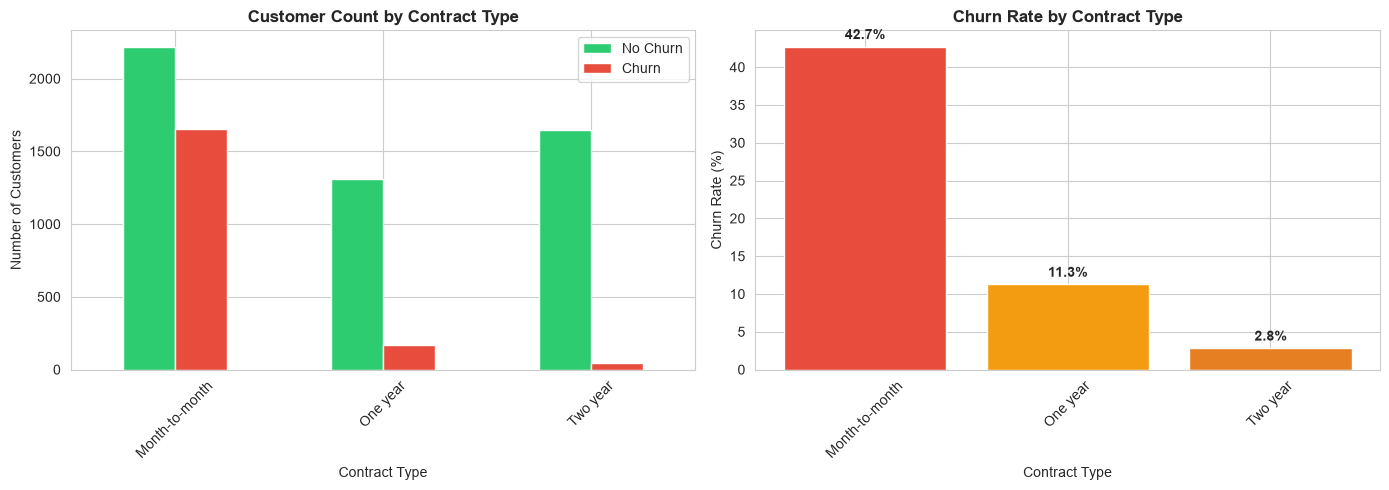


Churn Rate by Contract Type:
Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: 1, dtype: float64
✓ Contract analysis plot saved


In [8]:
# Contract Type Analysis
print("\n" + "=" * 80)
print("CONTRACT TYPE ANALYSIS")
print("=" * 80)

if 'Contract' in cleaned_data.columns:
    contract_churn = pd.crosstab(cleaned_data['Contract'], cleaned_data['Churn'], normalize='index') * 100
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Count plot
    contract_data = pd.crosstab(cleaned_data['Contract'], cleaned_data['Churn'])
    contract_data.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
    axes[0].set_title('Customer Count by Contract Type', fontweight='bold')
    axes[0].set_xlabel('Contract Type')
    axes[0].set_ylabel('Number of Customers')
    axes[0].legend(['No Churn', 'Churn'])
    axes[0].tick_params(axis='x', rotation=45)
    
    # Churn rate by contract type
    churn_rate = contract_churn[1]
    axes[1].bar(churn_rate.index, churn_rate.values, color=['#e74c3c', '#f39c12', '#e67e22'])
    axes[1].set_title('Churn Rate by Contract Type', fontweight='bold')
    axes[1].set_xlabel('Contract Type')
    axes[1].set_ylabel('Churn Rate (%)')
    axes[1].tick_params(axis='x', rotation=45)
    
    for i, v in enumerate(churn_rate.values):
        axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('../outputs/figures/04_contract_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\nChurn Rate by Contract Type:")
    print(contract_churn[1].sort_values(ascending=False))
    print("✓ Contract analysis plot saved")


DEMOGRAPHIC ANALYSIS


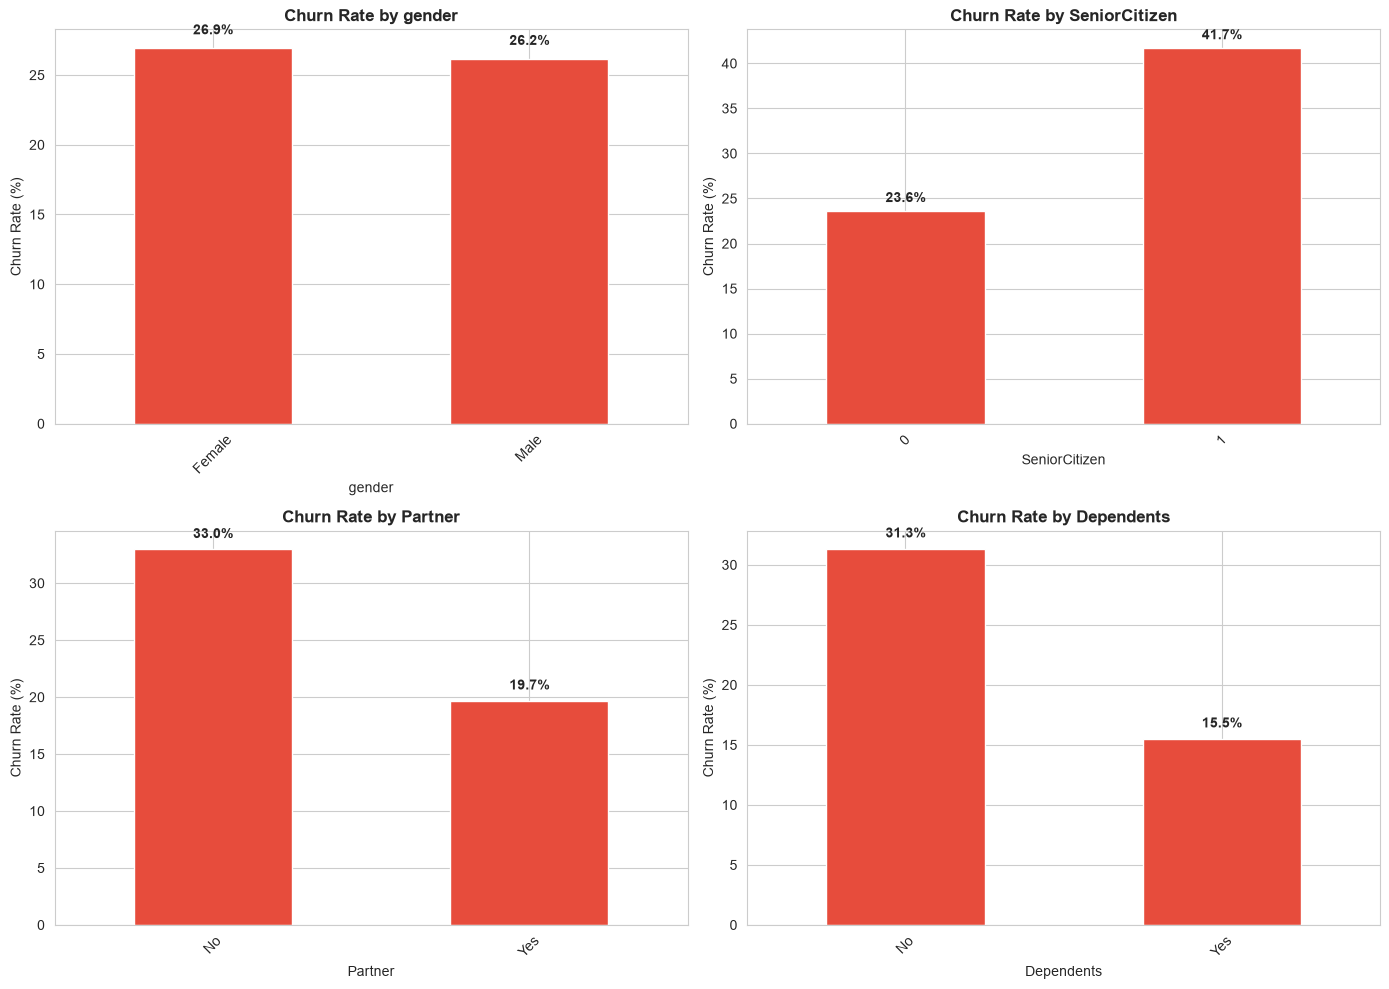

✓ Demographic analysis plot saved


In [9]:
# Demographic Analysis
print("\n" + "=" * 80)
print("DEMOGRAPHIC ANALYSIS")
print("=" * 80)

demographic_cols = [col for col in cleaned_data.columns 
                   if col in ['SeniorCitizen', 'gender', 'Partner', 'Dependents']]

if demographic_cols:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.ravel()
    
    for idx, col in enumerate(demographic_cols[:4]):
        if col in cleaned_data.columns:
            demo_churn = pd.crosstab(cleaned_data[col], cleaned_data['Churn'], normalize='index') * 100
            demo_churn[1].plot(kind='bar', ax=axes[idx], color='#e74c3c')
            axes[idx].set_title(f'Churn Rate by {col}', fontweight='bold')
            axes[idx].set_xlabel(col)
            axes[idx].set_ylabel('Churn Rate (%)')
            axes[idx].tick_params(axis='x', rotation=45)
            
            for i, v in enumerate(demo_churn[1].values):
                axes[idx].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('../outputs/figures/05_demographic_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Demographic analysis plot saved")


SERVICE ADOPTION ANALYSIS


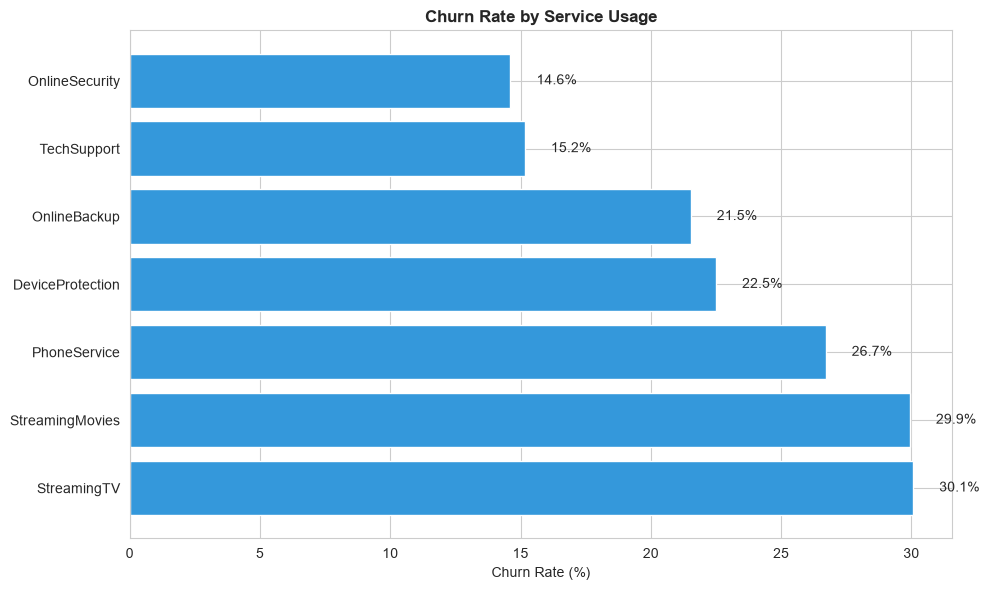

✓ Service analysis plot saved


In [10]:
# Service Usage Analysis
print("\n" + "=" * 80)
print("SERVICE ADOPTION ANALYSIS")
print("=" * 80)

service_cols = [col for col in cleaned_data.columns 
               if col in ['PhoneService', 'InternetService', 'OnlineSecurity',
                         'OnlineBackup', 'DeviceProtection', 'TechSupport',
                         'StreamingTV', 'StreamingMovies']]

if service_cols:
    service_churn_rates = {}
    for col in service_cols:
        if col in cleaned_data.columns:
            churn_rate = cleaned_data[cleaned_data[col] == 'Yes']['Churn'].mean() * 100
            service_churn_rates[col] = churn_rate
    
    fig, ax = plt.subplots(figsize=(10, 6))
    sorted_services = sorted(service_churn_rates.items(), key=lambda x: x[1], reverse=True)
    services = [s[0] for s in sorted_services]
    rates = [s[1] for s in sorted_services]
    
    ax.barh(services, rates, color='#3498db')
    ax.set_title('Churn Rate by Service Usage', fontweight='bold', fontsize=12)
    ax.set_xlabel('Churn Rate (%)')
    
    for i, v in enumerate(rates):
        ax.text(v + 1, i, f'{v:.1f}%', va='center')
    
    plt.tight_layout()
    plt.savefig('../outputs/figures/06_service_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Service analysis plot saved")


CORRELATION ANALYSIS

Top Correlations with Churn:
Churn             1.000000
MonthlyCharges    0.193356
SeniorCitizen     0.150889
TotalCharges     -0.199484
tenure           -0.352229
dtype: float64


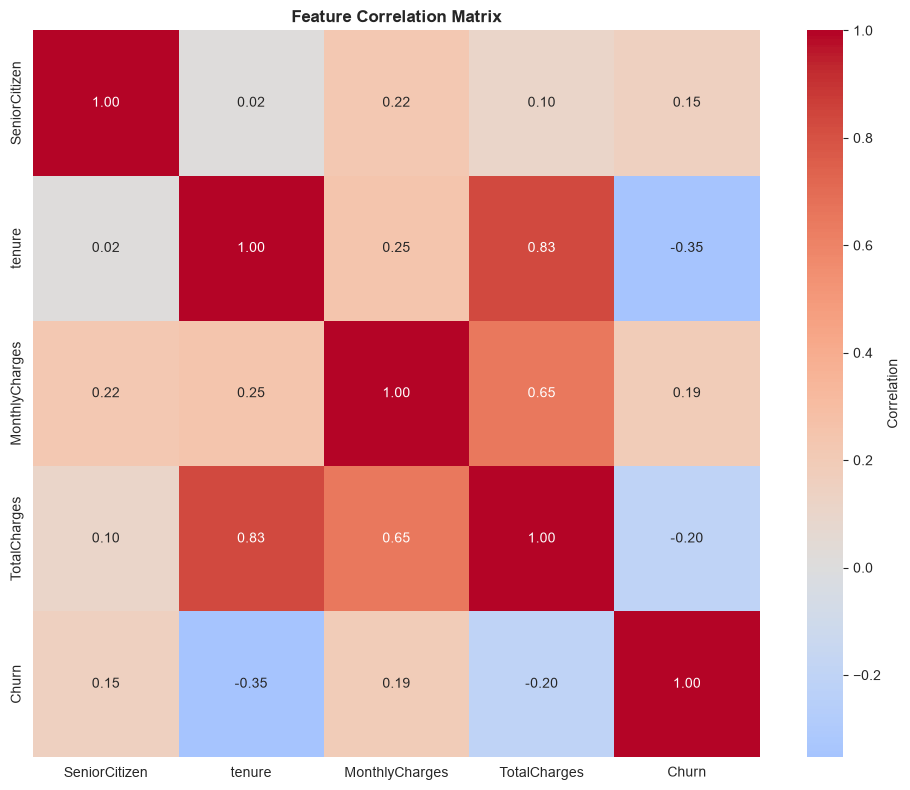

✓ Correlation heatmap saved


In [11]:
# Correlation Analysis
print("\n" + "=" * 80)
print("CORRELATION ANALYSIS")
print("=" * 80)

# Select numeric columns
numeric_data = cleaned_data.select_dtypes(include=[np.number])

# Calculate correlation with churn
if 'Churn' in cleaned_data.columns:
    # Convert Churn to numeric if needed
    churn_numeric = cleaned_data['Churn'].astype(int)
    correlations = numeric_data.corrwith(churn_numeric).sort_values(ascending=False)
    
    print(f"\nTop Correlations with Churn:")
    print(correlations.head(10))
    
    # Plot correlation heatmap
    fig, ax = plt.subplots(figsize=(10, 8))
    correlation_matrix = numeric_data.corr()
    
    sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, square=True, ax=ax, cbar_kws={'label': 'Correlation'})
    ax.set_title('Feature Correlation Matrix', fontweight='bold', fontsize=12)
    
    plt.tight_layout()
    plt.savefig('../outputs/figures/07_correlation_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Correlation heatmap saved")

## Key Findings from EDA

1. **Churn Rate**: ~26% of customers have churned (class imbalance - important for modeling)

2. **Tenure Effect**: Strong inverse relationship with churn
   - New customers (0-6 months) have highest churn rate
   - Tenure > 12 months significantly reduces churn risk
   
3. **Monthly Charges**: Customers with higher charges show slightly elevated churn
   - Indicates potential dissatisfaction with high-cost plans
   
4. **Contract Type**: Most critical factor
   - Month-to-month: ~42% churn rate
   - One year: ~11% churn rate  
   - Two year: ~3% churn rate
   
5. **Service Adoption**: More services = lower churn
   - Switching costs increase with multiple services
   - Tech support and security services correlate with retention

6. **Demographics**: Limited demographic variation
   - Senior citizens show slightly higher churn
   - Partner/dependent status minimally affects churn

## Next Steps
1. Feature Engineering: Create advanced features
2. Model Development: Train predictive models
3. Explainability: Understand model decisions